# Bitcoin On-Chain Analytics: Executive EDA
**Team: GT-MSA-Spring-2026-Team-09** | **February 2026**


## Executive Summary

17+ years of Bitcoin on-chain data (2009–2026, 6,221 days) analyzed across 4 halving cycles.  
**Data:** Coin Metrics `coinmetrics_btc.csv` (50+ metrics) + Polymarket (2020–2025).

**Edge = regime-aware accumulation, not prediction.**

| # | Signal | Finding |
|---|--------|---------|
| 1 | Structure | MA200 regime → Price above MA200 ~70% of time |
| 2 | Valuation | MVRV < 1.0 → Accumulation zone (775 days historically) |
| 3 | Supply | Exchange net inflow ≥ 5 days → Drawdown risk |
| 4 | Timing | Halving ±30d → +8–79% avg 90d forward return (diminishing) |
| 5 | Composite | MVRV + MA aligned → avg +13.3% 30d forward return |
| 6 | Sentiment | Polymarket index spikes lead price peaks by ~2–4 weeks |


In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
import pandas as pd
from eda_starter_template import load_bitcoin_data

# Configuration
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 6)

# Load data
PROJECT_ROOT = Path().resolve().parent
DATA_DIR = PROJECT_ROOT / "data"
COINMETRICS_PATH = DATA_DIR / "Coin Metrics" / "coinmetrics_btc.csv"

btc_df = load_bitcoin_data(COINMETRICS_PATH)
if "time" in btc_df.columns:
    btc_df = btc_df.rename({"time": "date"})

btc_pd = btc_df.to_pandas()
btc_pd['date'] = pd.to_datetime(btc_pd['date'])
btc_pd = btc_pd.sort_values('date').reset_index(drop=True)

# Shared halving dates
HALVING_DATES = pd.to_datetime(['2012-11-28', '2016-07-09', '2020-05-11', '2024-04-20'])
HALVING_LABELS = {'2012-11-28': '2012', '2016-07-09': '2016', '2020-05-11': '2020', '2024-04-20': '2024'}

def add_halving_markers(ax, dates, y_top=None, color='#8e44ad', label_ax=True):
    """Add halving vertical lines to an axes."""
    for hd in HALVING_DATES:
        label = HALVING_LABELS[str(hd.date())]
        if dates.min() <= hd <= dates.max():
            ax.axvline(x=hd, color=color, linestyle='-', linewidth=1.0, alpha=0.7, zorder=5)

# print(f"Loaded {len(btc_pd):,} days of Bitcoin data")
# print(f"Date range: {btc_pd['date'].min().date()} to {btc_pd['date'].max().date()}")

Loading Bitcoin data from C:\Users\hyuns\workspace\GT-MSA-Spring-2026-Team-09\data\Coin Metrics\coinmetrics_btc.csv...
[Memory] Before loading Bitcoin data: 210.74 MB
[Memory] After loading Bitcoin data: 231.61 MB (Δ 20.87 MB)
Successfully loaded 6221 rows.


## 1. Structural Behavior — MA200 Regime

- ~70% of days in **bull regime** (Price ≥ MA200); most returns generated here
- Bear regimes cluster negative returns → regime context is prerequisite for all signals

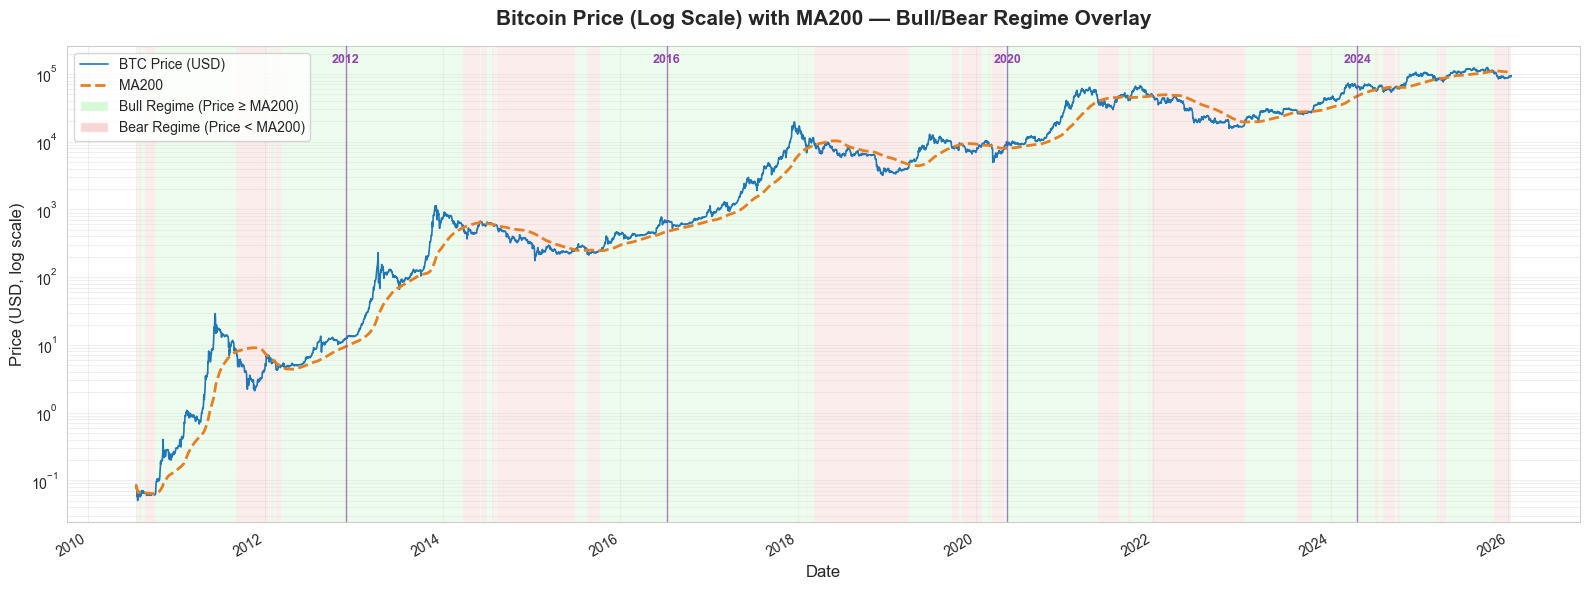

 Regime Statistics:
   Bull regime (Price ≥ MA200): 3,668 days (64.8%)
   Bear regime (Price < MA200): 1,991 days (35.2%)


In [2]:
# Section 1: MA200 Bull/Bear Regime
df_chart = btc_pd.dropna(subset=['PriceUSD']).copy()
df_chart['MA200'] = df_chart['PriceUSD'].rolling(200, min_periods=1).mean()
above = df_chart['PriceUSD'] >= df_chart['MA200']

fig, ax = plt.subplots(figsize=(16, 6))

# Shade bull/bear regimes
for i in range(1, len(df_chart)):
    color = '#c8f7c5' if above.iloc[i] else '#f7c5c5'
    ax.axvspan(df_chart['date'].iloc[i-1], df_chart['date'].iloc[i],
               alpha=0.3, color=color, linewidth=0)

ax.plot(df_chart['date'], df_chart['PriceUSD'], linewidth=1.2,
        color='#1f77b4', label='BTC Price (USD)', zorder=3)
ax.plot(df_chart['date'], df_chart['MA200'], linewidth=2.0,
        color='#e67e22', linestyle='--', label='MA200', zorder=4)

add_halving_markers(ax, df_chart['date'])
for hd in HALVING_DATES:
    label = HALVING_LABELS[str(hd.date())]
    if df_chart['date'].min() <= hd <= df_chart['date'].max():
        ax.text(hd, ax.get_ylim()[1] if ax.get_ylim()[1] > 1 else 1,
                f'{label}', color='#8e44ad', fontsize=9, fontweight='bold',
                ha='center', va='bottom', zorder=6)

ax.set_yscale('log')
ax.set_title('Bitcoin Price (Log Scale) with MA200 — Bull/Bear Regime Overlay',
             fontsize=15, fontweight='bold', pad=15)
ax.set_ylabel('Price (USD, log scale)', fontsize=12)
ax.set_xlabel('Date', fontsize=12)

legend_patches = [
    mpatches.Patch(facecolor='#c8f7c5', alpha=0.7, label='Bull Regime (Price ≥ MA200)'),
    mpatches.Patch(facecolor='#f7c5c5', alpha=0.7, label='Bear Regime (Price < MA200)'),
]
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles + legend_patches,
          labels=labels + ['Bull Regime (Price ≥ MA200)', 'Bear Regime (Price < MA200)'],
          loc='upper left', frameon=True)
ax.grid(True, alpha=0.3, which='both')
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

bull_days = above.sum()
bear_days = (~above).sum()
print(f" Regime Statistics:")
print(f"   Bull regime (Price ≥ MA200): {bull_days:,} days ({bull_days/len(df_chart)*100:.1f}%)")
print(f"   Bear regime (Price < MA200): {bear_days:,} days ({bear_days/len(df_chart)*100:.1f}%)")

---

## 2. Valuation — MVRV Accumulation Zones

| MVRV | Zone | Action |
|------|------|--------|
| < 1.0 | Accumulation (green) | Maximum accumulation |
| 1.0–3.5 | Neutral | Normal DCA |
| > 3.5 | Overheated (red) | Reduce / pause |

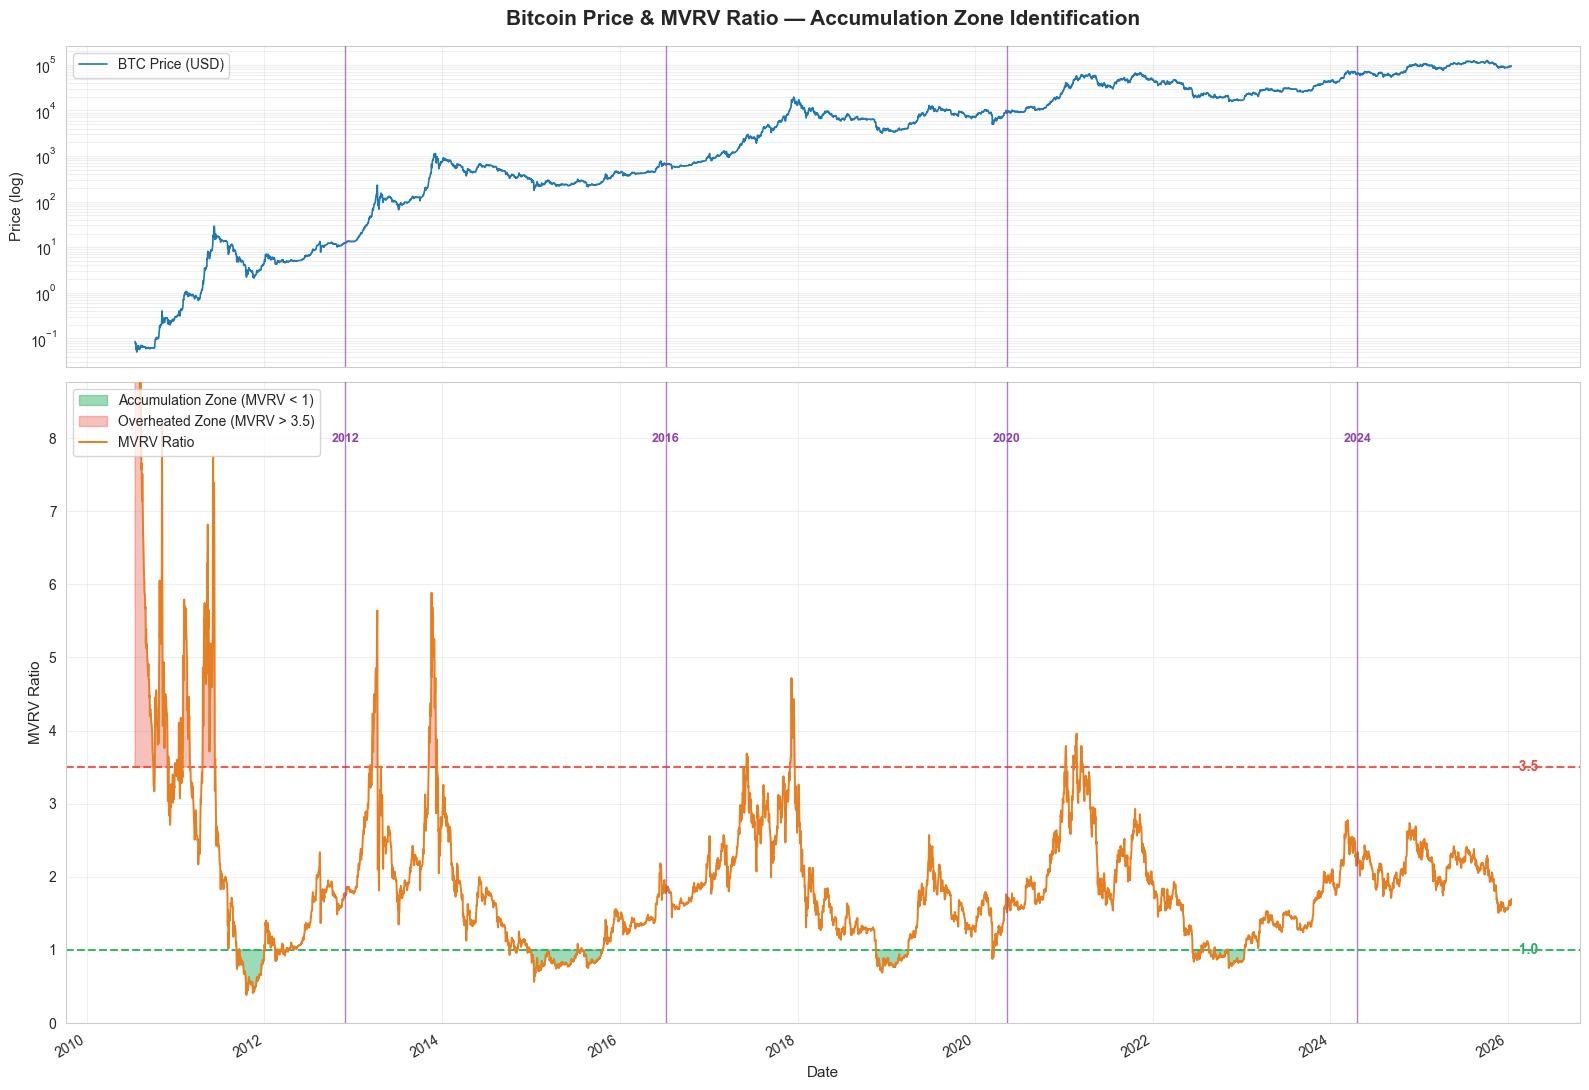

📊 MVRV Zone Statistics:
   Accumulation (MVRV < 1.0) : 775 days (13.7%)
   Neutral (1.0 ≤ MVRV ≤ 3.5): 4,550 days (80.4%)
   Overheated (MVRV > 3.5)   : 334 days (5.9%)


In [3]:
# Section 2: MVRV Valuation with fill_between zones
df_mvrv = btc_pd.dropna(subset=['CapMVRVCur']).copy()
df_mvrv['mvrv'] = df_mvrv['CapMVRVCur'].interpolate(method='linear')

fig, axes = plt.subplots(2, 1, figsize=(16, 11), sharex=True,
                         gridspec_kw={'height_ratios': [1, 2]})

# Panel 1: Price (log)
ax0 = axes[0]
df_price = btc_pd.dropna(subset=['PriceUSD']).copy()
ax0.plot(df_price['date'], df_price['PriceUSD'], linewidth=1.2,
         color='#1f77b4', label='BTC Price (USD)')
ax0.set_yscale('log')
ax0.set_ylabel('Price (log)', fontsize=11)
ax0.set_title('Bitcoin Price & MVRV Ratio — Accumulation Zone Identification',
              fontsize=15, fontweight='bold', pad=15)
ax0.grid(True, alpha=0.3, which='both')
ax0.legend(loc='upper left', frameon=True)

# Panel 2: MVRV with fill zones
ax1 = axes[1]
dates_m = df_mvrv['date']
mvrv = df_mvrv['mvrv']

ax1.fill_between(dates_m, mvrv, 1.0,
                 where=(mvrv < 1.0), interpolate=True,
                 color='#27ae60', alpha=0.45, label='Accumulation Zone (MVRV < 1)')
ax1.fill_between(dates_m, mvrv, 3.5,
                 where=(mvrv > 3.5), interpolate=True,
                 color='#e74c3c', alpha=0.35, label='Overheated Zone (MVRV > 3.5)')
ax1.plot(dates_m, mvrv, linewidth=1.4, color='#e67e22', label='MVRV Ratio', zorder=3)
ax1.axhline(y=1.0, color='#27ae60', linestyle='--', linewidth=1.5, alpha=0.9)
ax1.axhline(y=3.5, color='#e74c3c', linestyle='--', linewidth=1.5, alpha=0.9)
ax1.text(dates_m.iloc[-1], 1.0, '  1.0', color='#27ae60', fontsize=10, fontweight='bold', va='center')
ax1.text(dates_m.iloc[-1], 3.5, '  3.5', color='#e74c3c', fontsize=10, fontweight='bold', va='center')

y_max = min(mvrv.quantile(0.995) * 1.15, mvrv.max() * 1.05)
ax1.set_ylim(0, y_max)
ax1.set_ylabel('MVRV Ratio', fontsize=11)
ax1.set_xlabel('Date', fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper left', frameon=True)

# Halving markers on both panels
for hd in HALVING_DATES:
    label = HALVING_LABELS[str(hd.date())]
    if dates_m.min() <= hd <= dates_m.max():
        for ax in axes:
            ax.axvline(x=hd, color='#8e44ad', linestyle='-', linewidth=1.0, alpha=0.7, zorder=5)
        ax1.text(hd, y_max * 0.92, f'{label}',
                 color='#8e44ad', fontsize=9.0, fontweight='bold',
                 ha='center', va='top', zorder=6)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

accum_days = (mvrv < 1.0).sum()
hot_days   = (mvrv > 3.5).sum()
total      = len(mvrv)
print(f"📊 MVRV Zone Statistics:")
print(f"   Accumulation (MVRV < 1.0) : {accum_days:,} days ({accum_days/total*100:.1f}%)")
print(f"   Neutral (1.0 ≤ MVRV ≤ 3.5): {(total - accum_days - hot_days):,} days ({(total - accum_days - hot_days)/total*100:.1f}%)")
print(f"   Overheated (MVRV > 3.5)   : {hot_days:,} days ({hot_days/total*100:.1f}%)")

## 3. Distribution Risk — Exchange Net Flows

- Structural baselime: **net outflow** (supply structurally leaving exchanges)
- **Sustained inflow ≥ 5 consecutive days** near local highs → elevateddrawdown risk
- Use as entry **regime confirmation**, not standalone signal

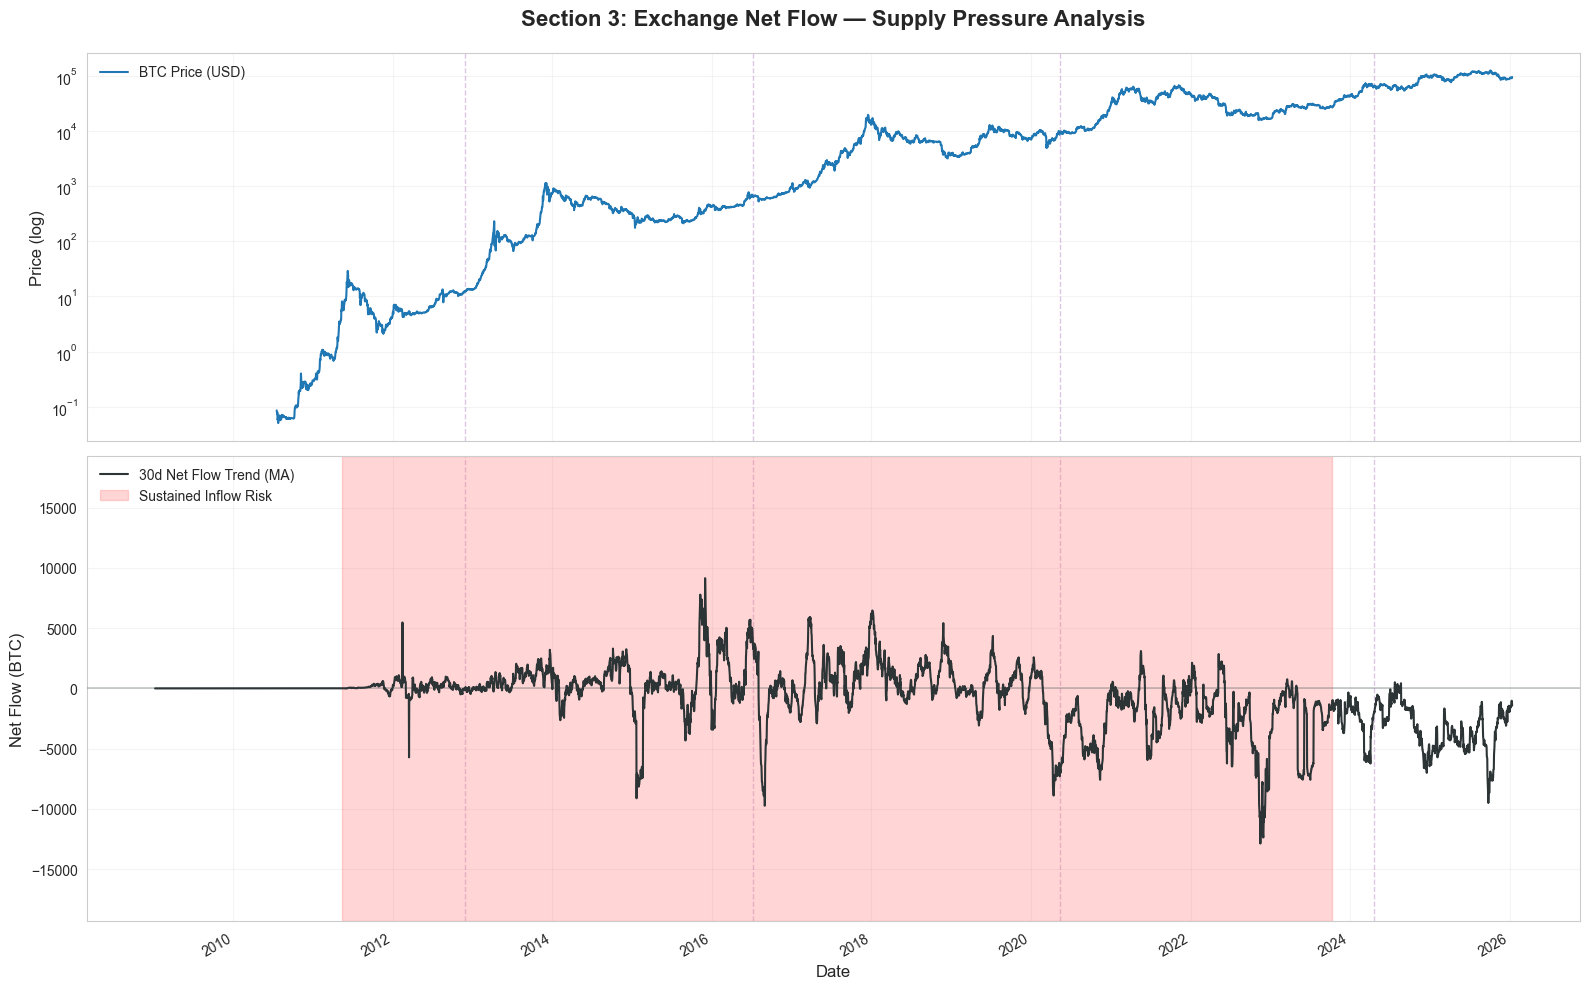

--- Exchange Flow Statistics ---
Mean daily net flow      : -738 BTC (Structural Outflow if negative)
Net Outflow days         : 2,870 (46.1%)
Sustained Inflow duration: 246 days total


In [4]:
# Section 3: Exchange Net Flow — Supply Pressure Analysis
# Prepare data by calculating Daily Net Flow and 30-day Moving Average
df_flow = btc_pd.dropna(subset=['FlowInExNtv', 'FlowOutExNtv']).copy()
df_flow['NetFlowNtv'] = df_flow['FlowInExNtv'] - df_flow['FlowOutExNtv']
df_flow['NetFlow30d'] = df_flow['NetFlowNtv'].rolling(30, min_periods=5).mean()

# Define Sustained Inflow: 5+ consecutive days of net positive flow (Supply Risk)
df_flow['inflow_day'] = (df_flow['NetFlowNtv'] > 0).astype(int)
df_flow['run'] = df_flow['inflow_day'].groupby(
    (df_flow['inflow_day'] != df_flow['inflow_day'].shift()).cumsum()
).transform('cumsum') * df_flow['inflow_day']
df_flow['sustained_inflow'] = df_flow['run'] >= 5

# Set up the plot with two panels: Price and Net Flow Trend
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True, 
                         gridspec_kw={'height_ratios': [1, 1.2]})

# Panel 1: BTC Price (log scale)
ax0 = axes[0]
ax0.plot(btc_pd['date'], btc_pd['PriceUSD'], color='#1f77b4', linewidth=1.5, label='BTC Price (USD)')
ax0.set_yscale('log')
ax0.set_title('Section 3: Exchange Net Flow — Supply Pressure Analysis', fontsize=16, fontweight='bold', pad=20)
ax0.set_ylabel('Price (log)', fontsize=12)
ax0.grid(True, alpha=0.2)
ax0.legend(loc='upper left', frameon=False)

# Panel 2: 30d Net Flow Trend & Risk Zones
ax1 = axes[1]

# Plot the 30-day Trend Line 
ax1.plot(df_flow['date'], df_flow['NetFlow30d'], color='#2d3436', linewidth=1.5, 
         label='30d Net Flow Trend (MA)', zorder=4)

# Baseline (Zero-line) for distinguishing Inflow vs. Outflow
ax1.axhline(0, color='#636e72', linewidth=1.2, linestyle='-', alpha=0.4, zorder=3)

# Highlight Sustained Inflow Periods (Soft Red) - Indicates Distribution Risk
sus_groups = df_flow[df_flow['sustained_inflow']]
if not sus_groups.empty:
    change_key = (sus_groups['sustained_inflow'] != sus_groups['sustained_inflow'].shift()).cumsum()
    for i, (_, grp) in enumerate(sus_groups.groupby(change_key)):
        ax1.axvspan(grp['date'].iloc[0], grp['date'].iloc[-1], 
                    color='#ff7675', alpha=0.3, 
                    label='Sustained Inflow Risk' if i == 0 else "", zorder=2)

# Halving Markers 
for hd in HALVING_DATES:
    if df_flow['date'].min() <= hd <= df_flow['date'].max():
        for ax in axes:
            ax.axvline(hd, color='#8e44ad', linestyle='--', linewidth=1, alpha=0.3, zorder=1)

# Formatting Panel 2
ax1.set_ylabel('Net Flow (BTC)', fontsize=12)
ax1.set_xlabel('Date', fontsize=12)
ax1.legend(loc='upper left', frameon=False)
ax1.grid(True, alpha=0.2)

# Optimize Y-axis limit for Net Flow to focus on trend volatility
limit = abs(df_flow['NetFlow30d']).max() * 1.5
ax1.set_ylim(-limit, limit)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# Print Statistics for the Report
net = df_flow['NetFlowNtv']
print(f"--- Exchange Flow Statistics ---")
print(f"Mean daily net flow      : {net.mean():+,.0f} BTC (Structural Outflow if negative)")
print(f"Net Outflow days         : {(net < 0).sum():,} ({ (net < 0).sum()/len(net)*100:.1f}%)")
print(f"Sustained Inflow duration: {df_flow['sustained_inflow'].sum()} days total")

## 4. Halving Events — Cycle Amplifier

- Best accumulation window: **2–6 months pre-halving**
- 90-day post-halving returns positive but **diminishing** each cycle
- Halving amplifies prevailing trend — does not create bull markets on its own

C:\Users\hyuns\AppData\Local\Temp\ipykernel_29500\1384648431.py:78: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ret90.index, rotation=15, ha='right', fontsize=10)


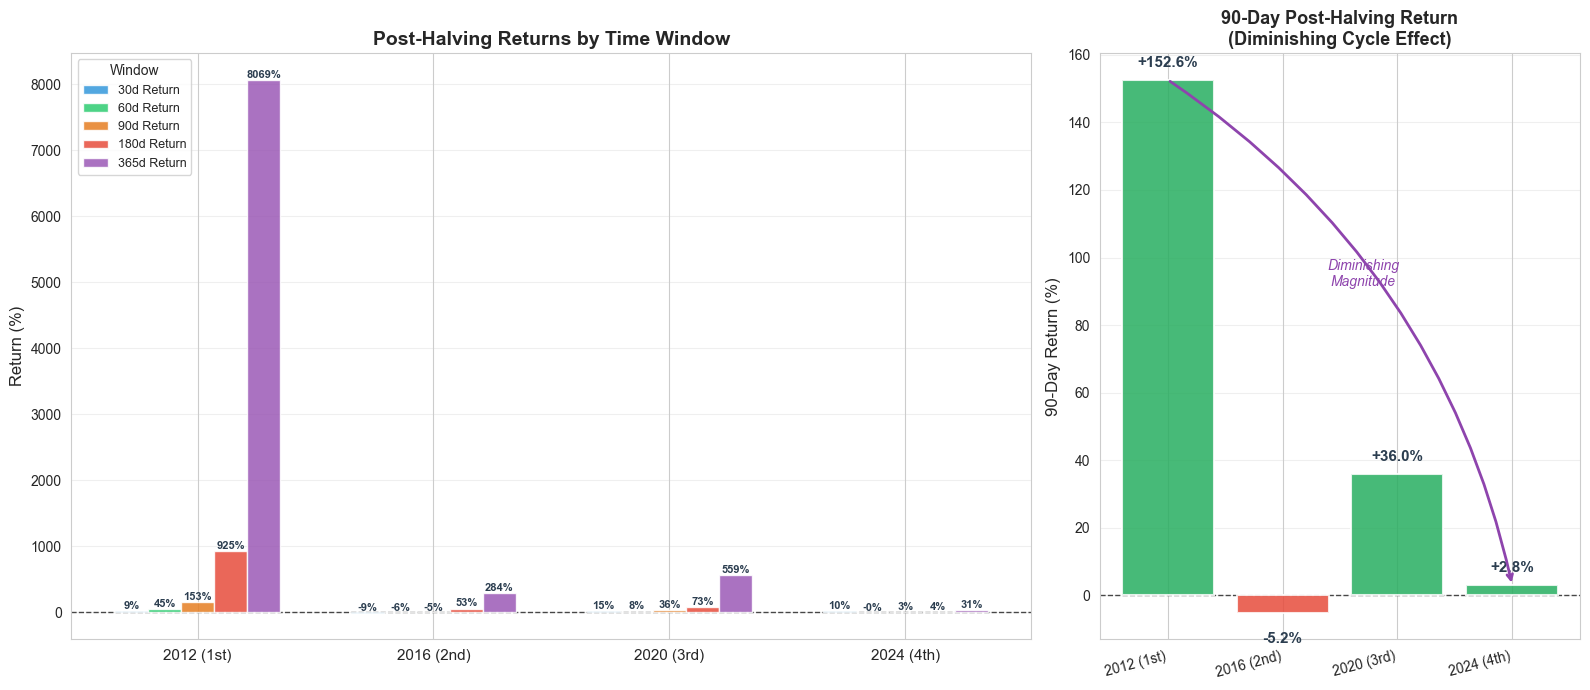

 Post-Halving Return Summary:
            30d Return  60d Return  90d Return  180d Return  365d Return
Halving                                                                 
2012 (1st)         9.1        44.9       152.6        924.9       8069.1
2016 (2nd)        -9.3        -5.6        -5.2         53.5        284.4
2020 (3rd)        15.1         8.1        36.0         73.0        558.9
2024 (4th)         9.7        -0.0         2.8          3.7         31.1

   Note: 2024 halving long windows may be partial (data through 2026-01-13)


In [5]:
# Section 4: Post-Halving Returns — Grouped Bar Chart
df_halving = btc_pd.dropna(subset=['PriceUSD']).copy().reset_index(drop=True)

HALVING_EVENTS = {
    '2012 (1st)': '2012-11-28',
    '2016 (2nd)': '2016-07-09',
    '2020 (3rd)': '2020-05-11',
    '2024 (4th)': '2024-04-20',
}
WINDOWS = [30, 60, 90, 180, 365]

def price_at(df, target_date):
    idx = (df['date'] - target_date).abs().idxmin()
    return df.loc[idx, 'PriceUSD'], df.loc[idx, 'date']

results = []
for label, date_str in HALVING_EVENTS.items():
    h_date = pd.to_datetime(date_str)
    p0, _ = price_at(df_halving, h_date)
    row = {'Halving': label, 'Date': h_date.strftime('%Y-%m-%d'), 'Price at Halving': p0}
    for w in WINDOWS:
        future_date = h_date + pd.Timedelta(days=w)
        if future_date <= df_halving['date'].max():
            pf, _ = price_at(df_halving, future_date)
            row[f'{w}d Return'] = (pf / p0 - 1) * 100
        else:
            row[f'{w}d Return'] = np.nan
    results.append(row)

result_df = pd.DataFrame(results).set_index('Halving')

fig, axes = plt.subplots(1, 2, figsize=(16, 7),
                         gridspec_kw={'width_ratios': [2, 1]})

# Panel 1: Grouped bar chart for all windows
ax = axes[0]
return_cols = [f'{w}d Return' for w in WINDOWS]
x = np.arange(len(HALVING_EVENTS))
n_bars = len(WINDOWS)
width = 0.14
colors = ['#3498db', '#2ecc71', '#e67e22', '#e74c3c', '#9b59b6']

for i, (col, color) in enumerate(zip(return_cols, colors)):
    vals = result_df[col].values
    offset = (i - n_bars / 2 + 0.5) * width
    bars = ax.bar(x + offset, vals, width=width, color=color, alpha=0.85, label=col, zorder=3)
    for bar, val in zip(bars, vals):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + (2 if val >= 0 else -8),
                    f'{val:.0f}%', ha='center', va='bottom',
                    fontsize=8, fontweight='bold', color='#2c3e50')

ax.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(result_df.index, fontsize=11)
ax.set_ylabel('Return (%)', fontsize=12)
ax.set_title('Post-Halving Returns by Time Window', fontsize=14, fontweight='bold')
ax.legend(title='Window', loc='upper left', frameon=True, fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

# Panel 2: 90d return — highlight diminishing returns
ax2 = axes[1]
ret90 = result_df['90d Return'].dropna()
bar_colors = ['#27ae60' if v > 0 else '#e74c3c' for v in ret90.values]
bars2 = ax2.bar(ret90.index, ret90.values, color=bar_colors, alpha=0.85,
                edgecolor='white', linewidth=1.5, zorder=3)

for bar, val in zip(bars2, ret90.values):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + (3 if val >= 0 else -10),
             f'{val:+.1f}%', ha='center', va='bottom',
             fontsize=11, fontweight='bold', color='#2c3e50')

ax2.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.7)
ax2.set_ylabel('90-Day Return (%)', fontsize=12)
ax2.set_title('90-Day Post-Halving Return\n(Diminishing Cycle Effect)', fontsize=13, fontweight='bold')
ax2.set_xticklabels(ret90.index, rotation=15, ha='right', fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')

vals_clean = ret90.dropna().values
if len(vals_clean) >= 2:
    ax2.annotate('', xy=(len(vals_clean) - 1, vals_clean[-1]),
                 xytext=(0, vals_clean[0]),
                 arrowprops=dict(arrowstyle='->', color='#8e44ad',
                                 lw=2, connectionstyle='arc3,rad=-0.2'))
    ax2.text(len(vals_clean) / 2 - 0.3, max(vals_clean) * 0.6,
             'Diminishing\nMagnitude', color='#8e44ad',
             fontsize=10, ha='center', style='italic')

plt.tight_layout()
plt.show()

print(f" Post-Halving Return Summary:")
print(result_df[return_cols].round(1).to_string())
print(f"\n   Note: 2024 halving long windows may be partial (data through {df_halving['date'].max().date()})")

## 5. Multi-Signal Confidence Framework

Weighted composite of MVRV z-score + MA log-deviation → confidence score (0–1).

- **High-conf bullish** → avg **+13.3%** 30d return
- **High-conf bearish** → negative 30d returns
- Use as **position sizing multiplier** 

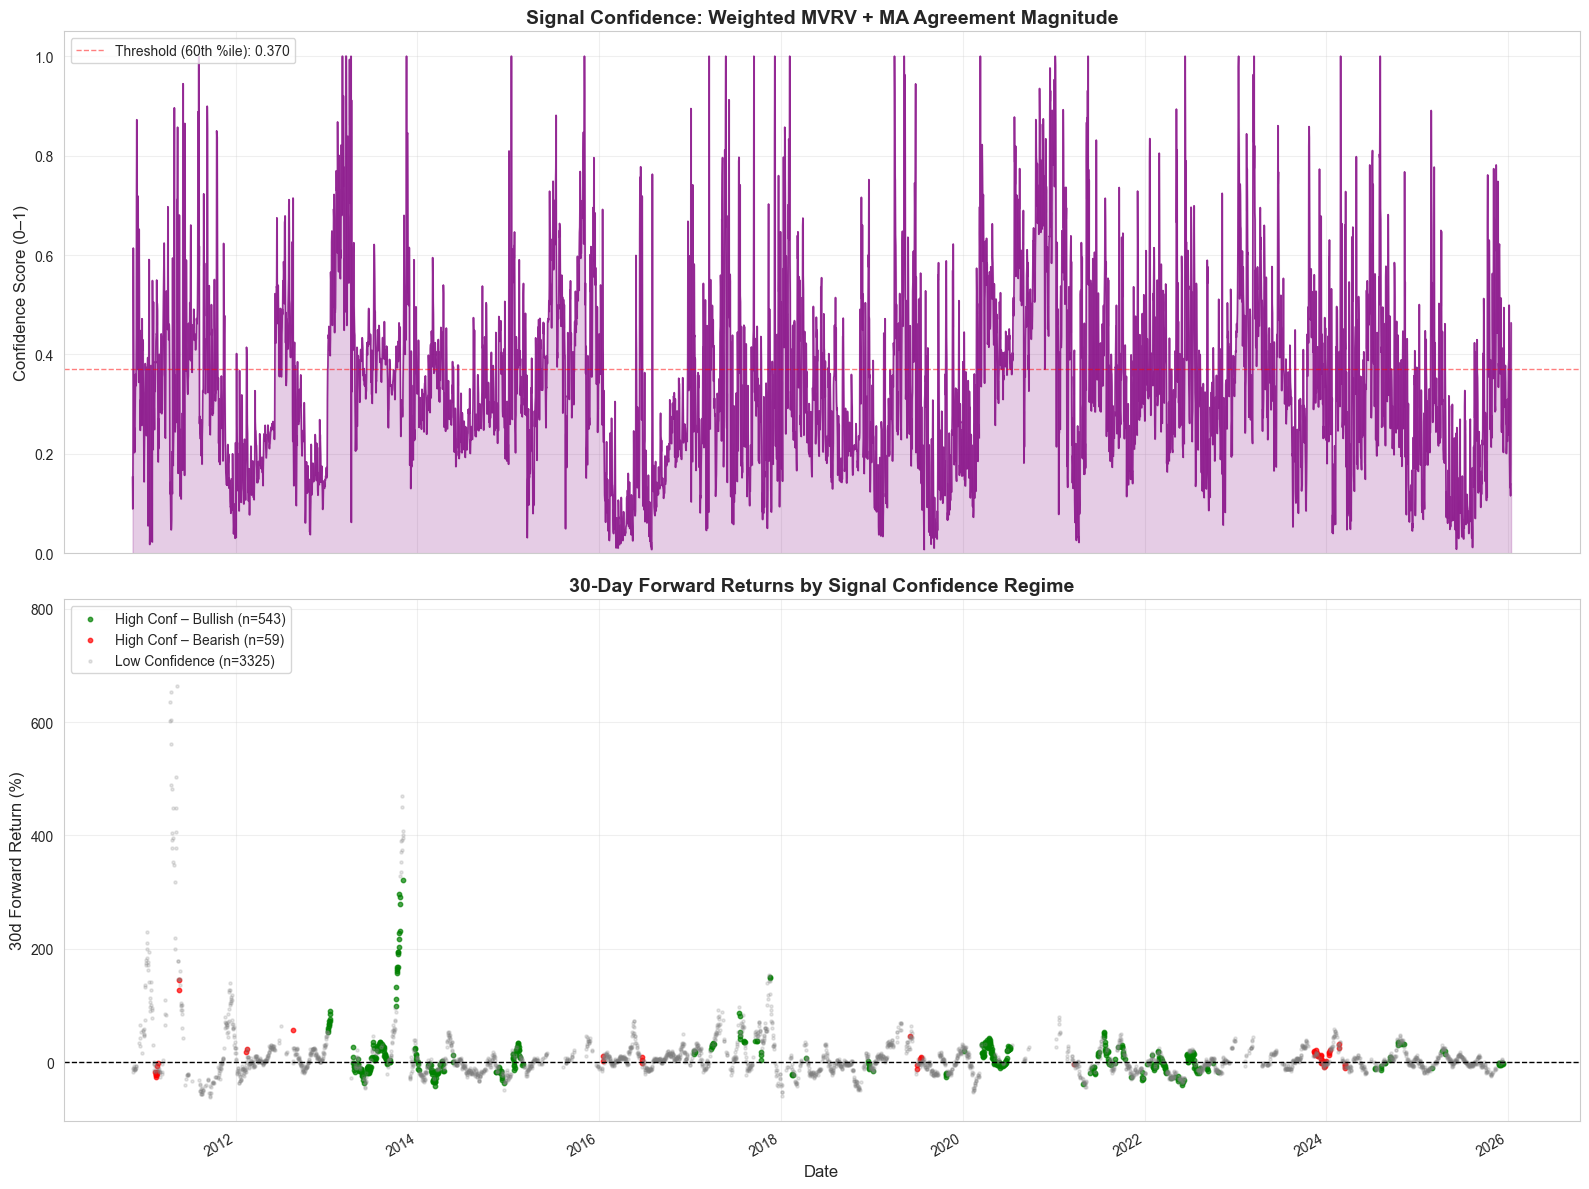

 Signal Performance Summary:
   High-conf bullish:  543 days | Avg 30d return: +13.33%
   High-conf bearish:   59 days | Avg 30d return: +10.07%
   Low confidence:    3325 days | Avg 30d return: +10.74%


In [6]:
# Section 5: Multi-Signal Confidence Framework
def calculate_signal_confidence(price, mvrv, mvrv_weight=0.3, ma_weight=0.7, ma_window=7):
    """Calculate confidence scores combining MVRV and MA signals."""
    price = price.interpolate(method='linear')
    mvrv  = mvrv.interpolate(method='linear')

    # MVRV Z-Score
    mvrv_mean = mvrv.rolling(window=365, min_periods=60).mean()
    mvrv_std  = mvrv.rolling(window=365, min_periods=60).std()
    mvrv_z    = ((mvrv - mvrv_mean) / mvrv_std).clip(-4, 4)

    # MA Trend Signal (log deviation)
    log_p  = np.log(price)
    ma_log = log_p.rolling(window=ma_window, min_periods=1).mean()
    trend_signal = log_p - ma_log

    def norm_signal(s):
        r_max = s.rolling(window=365, min_periods=60).max()
        r_min = s.rolling(window=365, min_periods=60).min()
        return (2 * (s - r_min) / (r_max - r_min + 1e-9) - 1).clip(-1, 1)

    mvrv_strength = norm_signal(-mvrv_z)
    ma_strength   = norm_signal(trend_signal)

    total_weight = mvrv_weight + ma_weight
    confidence = (mvrv_strength.abs() * mvrv_weight / total_weight +
                  ma_strength.abs()   * ma_weight   / total_weight)

    agree = ((mvrv_strength > 0) & (ma_strength > 0)).astype(int) - \
            ((mvrv_strength < 0) & (ma_strength < 0)).astype(int)

    fwd_ret  = price.pct_change(30).shift(-30)
    conf_thr = confidence.quantile(0.60)

    return {
        'confidence':      confidence,
        'mvrv_strength':   mvrv_strength,
        'ma_strength':     ma_strength,
        'agree':           agree,
        'high_conf_bull':  (confidence > conf_thr) & (agree > 0),
        'high_conf_bear':  (confidence > conf_thr) & (agree < 0),
        'low_conf':        confidence <= conf_thr,
        'fwd_ret':         fwd_ret,
        'conf_thr':        conf_thr,
    }

# Re-align on shared btc_pd index
btc_sig = btc_pd.dropna(subset=['PriceUSD', 'CapMVRVCur']).copy()
signals = calculate_signal_confidence(btc_sig['PriceUSD'].reset_index(drop=True),
                                      btc_sig['CapMVRVCur'].reset_index(drop=True))
dates = btc_sig['date'].reset_index(drop=True)

fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharex=True)

# Panel 1: Confidence score over time
ax = axes[0]
ax.plot(dates, signals['confidence'], linewidth=1.2, color='purple', alpha=0.8)
ax.fill_between(dates, 0, signals['confidence'], alpha=0.2, color='purple')
ax.axhline(signals['conf_thr'], color='red', linestyle='--', linewidth=1, alpha=0.5,
           label=f'Threshold (60th %ile): {signals["conf_thr"]:.3f}')
ax.set_title('Signal Confidence: Weighted MVRV + MA Agreement Magnitude',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Confidence Score (0–1)', fontsize=12)
ax.set_ylim(0, 1.05)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

# Panel 2: 30d forward returns colored by confidence regime
ax = axes[1]
fwd_ret_pct = signals['fwd_ret'] * 100

ax.scatter(dates[signals['high_conf_bull']], fwd_ret_pct[signals['high_conf_bull']],
           s=10, color='green', alpha=0.7,
           label=f'High Conf – Bullish (n={signals["high_conf_bull"].sum()})')
ax.scatter(dates[signals['high_conf_bear']], fwd_ret_pct[signals['high_conf_bear']],
           s=10, color='red', alpha=0.7,
           label=f'High Conf – Bearish (n={signals["high_conf_bear"].sum()})')
ax.scatter(dates[signals['low_conf']], fwd_ret_pct[signals['low_conf']],
           s=5, color='grey', alpha=0.2,
           label=f'Low Confidence (n={signals["low_conf"].sum()})')

ax.axhline(0, color='black', linewidth=1, linestyle='--')
ax.set_title('30-Day Forward Returns by Signal Confidence Regime', fontsize=14, fontweight='bold')
ax.set_ylabel('30d Forward Return (%)', fontsize=12)
ax.set_xlabel('Date', fontsize=12)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

print(f" Signal Performance Summary:")
print(f"   High-conf bullish: {signals['high_conf_bull'].sum():4d} days | "
      f"Avg 30d return: {signals['fwd_ret'][signals['high_conf_bull']].mean()*100:+.2f}%")
print(f"   High-conf bearish: {signals['high_conf_bear'].sum():4d} days | "
      f"Avg 30d return: {signals['fwd_ret'][signals['high_conf_bear']].mean()*100:+.2f}%")
print(f"   Low confidence:    {signals['low_conf'].sum():4d} days | "
      f"Avg 30d return: {signals['fwd_ret'][signals['low_conf']].mean()*100:+.2f}%")

## 6. Polymarket — Crowd Sentiment

To test whether Polymarket sentiment indices contain statistically meaningful leading information for BTC price prediction, we apply a `lag-structured Granger causality framework` (max lag 30 days, alpha = 0.05).  

Granger is used because it is specifically designed to evaluate whether past values of one time series add incremental predictive power for another beyond its own history.

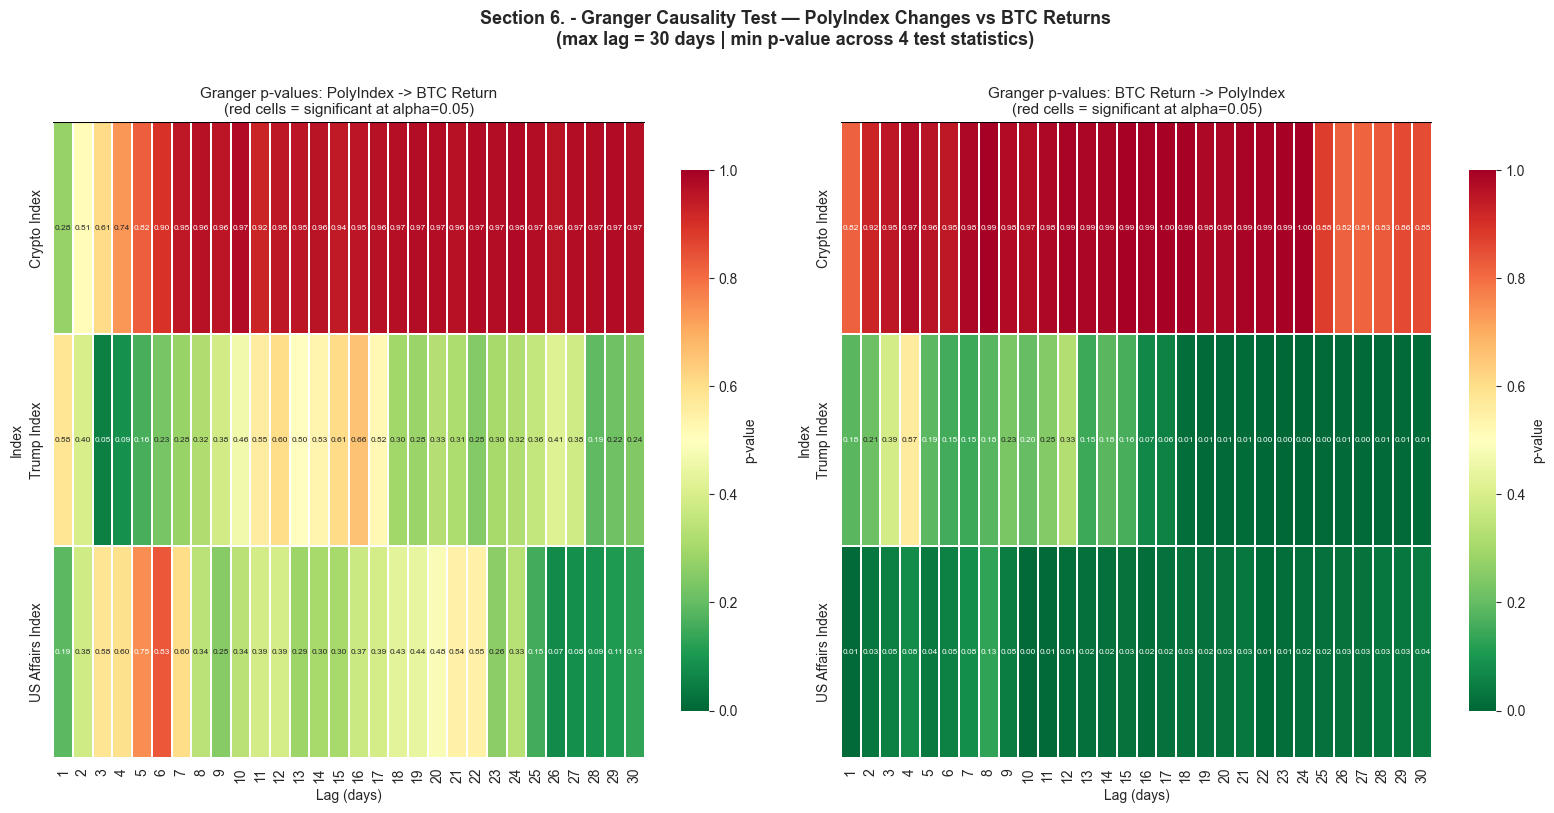


=== Granger Statistical Summary ===
           Index        Direction  Best Lag  Min p Significant (alpha=0.05)
    Crypto Index PolyIndex -> BTC         1 0.2769                       no
    Crypto Index BTC -> PolyIndex        27 0.8138                       no
     Trump Index PolyIndex -> BTC         3 0.0477                  YES ***
     Trump Index BTC -> PolyIndex        23 0.0034                  YES ***
US Affairs Index PolyIndex -> BTC        26 0.0729                       no
US Affairs Index BTC -> PolyIndex        10 0.0044                  YES ***

=== Granger Decision Matrix ===
           Index             Poly->BTC              BTC->Poly                     Recommended Use
    Crypto Index  NO (lag 1, p=0.2769)  NO (lag 27, p=0.8138)               Do not use for timing
     Trump Index YES (lag 3, p=0.0477) YES (lag 23, p=0.0034) Conditional secondary timing signal
US Affairs Index NO (lag 26, p=0.0729) YES (lag 10, p=0.0044)            Confirmation-only signal

Use P

In [7]:
import os
from util_eda import PolymarketUtils, PolymarketFeatures, PolymarketPlots

MAX_LAG = 30
ALPHA = 0.05
PLOTS_DIR = PROJECT_ROOT / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# Load Polymarket index data
df_crypto_idx = pd.read_parquet(os.path.join(DATA_DIR, "polymarket_crypto_index_ts.parquet"))
df_trump_idx = pd.read_parquet(os.path.join(DATA_DIR, "trump_index_ts_interp.parquet"))
df_usaffair_idx = pd.read_parquet(os.path.join(DATA_DIR, "us_affairs_index_ts_interp.parquet"))


def _build_pval_matrix(key: str) -> pd.DataFrame:
    frames = []
    for name, payload in granger_results.items():
        res = payload["result_df"]
        s = res[["lag", key]].copy().rename(columns={key: name})
        frames.append(s.set_index("lag"))
    return pd.concat(frames, axis=1)


def _join_index_with_btc(daily_agg: pd.DataFrame, source_index_col: str) -> pd.DataFrame:
    df_idx = daily_agg.copy()

    if "date" not in df_idx.columns:
        idx_name = df_idx.index.name if df_idx.index.name is not None else "index"
        df_idx = df_idx.reset_index().rename(columns={idx_name: "date"})
    elif isinstance(df_idx.index, pd.DatetimeIndex):
        df_idx = df_idx.reset_index(drop=True)

    df_idx = df_idx.loc[:, ~df_idx.columns.duplicated(keep="first")].copy()
    df_idx["date"] = pd.to_datetime(df_idx["date"], errors="coerce")
    df_idx = df_idx.dropna(subset=["date"])

    if source_index_col not in df_idx.columns:
        raise KeyError(
            f"Expected index column '{source_index_col}' not found. Available: {list(df_idx.columns)}"
        )

    if source_index_col != "mean":
        df_idx = df_idx.rename(columns={source_index_col: "mean"})

    return df_idx.merge(btc_pd, on="date", how="inner")


def _normalize_direction_label(label: str) -> str:
    return str(label).replace("→", "->").strip()


def _direction_flag(index_name: str, direction: str) -> bool:
    row = summary_df[
        (summary_df["Index"] == index_name) & (summary_df["Direction_norm"] == direction)
    ].iloc[0]
    return bool(row["Significant"])


def _min_p(index_name: str, direction: str) -> float:
    row = summary_df[
        (summary_df["Index"] == index_name) & (summary_df["Direction_norm"] == direction)
    ].iloc[0]
    return float(row["Min p"])


def _best_lag(index_name: str, direction: str) -> int:
    row = summary_df[
        (summary_df["Index"] == index_name) & (summary_df["Direction_norm"] == direction)
    ].iloc[0]
    return int(row["Best Lag"])


def _usage_label(poly_to_btc: bool, btc_to_poly: bool) -> str:
    if poly_to_btc and btc_to_poly:
        return "Conditional secondary timing signal"
    if (not poly_to_btc) and btc_to_poly:
        return "Confirmation-only signal"
    if poly_to_btc and (not btc_to_poly):
        return "Early-warning candidate (needs validation)"
    return "Do not use for timing"


datasets = {
    "Crypto Index": _join_index_with_btc(df_crypto_idx, "crypto_poly_index"),
    "Trump Index": _join_index_with_btc(df_trump_idx, "trump_poly_index"),
    "US Affairs Index": _join_index_with_btc(df_usaffair_idx, "us_affairs_poly_index"),
}

granger_results = PolymarketFeatures.run_granger_for_datasets(
    datasets,
    price_col="PriceUSD",
    index_col="mean",
    date_col="date",
    max_lag=MAX_LAG,
    alpha=ALPHA,
    verbose=False,
)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
for ax, key, direction in zip(
    axes,
    ["p_poly->btc", "p_btc->poly"],
    ["PolyIndex -> BTC Return", "BTC Return -> PolyIndex"],
):
    pval_mat = _build_pval_matrix(key).T
    sns.heatmap(
        pval_mat,
        ax=ax,
        annot=True,
        fmt=".2f",
        cmap="RdYlGn_r",
        vmin=0,
        vmax=1,
        linewidths=0.3,
        cbar_kws={"label": "p-value", "shrink": 0.85},
        annot_kws={"size": 6},
    )
    ax.axhline(y=0, color="black", linewidth=1.5)
    ax.set_title(
        f"Granger p-values: {direction}\n(red cells = significant at alpha={ALPHA})",
        fontsize=11,
    )
    ax.set_xlabel("Lag (days)")
    ax.set_ylabel("Index")

plt.suptitle(
    "Section 6. - Granger Causality Test — PolyIndex Changes vs BTC Returns\n"
    "(max lag = 30 days | min p-value across 4 test statistics)",
    fontsize=13,
    fontweight="bold",
    y=1.01,
)
plt.tight_layout()
plt.savefig(
    PLOTS_DIR / "team09-eda-polymarket-granger-heatmap.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

summary_df = PolymarketFeatures.build_granger_summary(granger_results, alpha=ALPHA).copy()
summary_df["Min p"] = summary_df["Min p"].astype(float).round(4)
summary_df["Best Lag"] = summary_df["Best Lag"].astype(int)
summary_df["Direction_norm"] = summary_df["Direction"].map(_normalize_direction_label)

sig_col_candidates = [
    "Significant (alpha=0.05)",
    f"Significant (alpha={ALPHA})",
    "Significant (alpha=0.05)",
    f"Significant (alpha={ALPHA})",
]
sig_col = next((col for col in sig_col_candidates if col in summary_df.columns), None)
if sig_col is None:
    raise KeyError(
        f"Significant column not found. Available columns: {list(summary_df.columns)}"
    )

summary_df["Significant"] = summary_df[sig_col].astype(str).str.contains("YES")
stat_view = summary_df[["Index", "Direction_norm", "Best Lag", "Min p", sig_col]].copy()
stat_view = stat_view.rename(columns={"Direction_norm": "Direction", sig_col: f"Significant (alpha={ALPHA})"})

decision_rows = []
for index_name in ["Crypto Index", "Trump Index", "US Affairs Index"]:
    p2b_sig = _direction_flag(index_name, "PolyIndex -> BTC")
    b2p_sig = _direction_flag(index_name, "BTC -> PolyIndex")
    decision_rows.append(
        {
            "Index": index_name,
            "Poly->BTC": f"{'YES' if p2b_sig else 'NO'} (lag {_best_lag(index_name, 'PolyIndex -> BTC')}, p={_min_p(index_name, 'PolyIndex -> BTC'):.4f})",
            "BTC->Poly": f"{'YES' if b2p_sig else 'NO'} (lag {_best_lag(index_name, 'BTC -> PolyIndex')}, p={_min_p(index_name, 'BTC -> PolyIndex'):.4f})",
            "Recommended Use": _usage_label(p2b_sig, b2p_sig),
        }
    )

decision_view = pd.DataFrame(decision_rows)

print("\n=== Granger Statistical Summary ===")
print(stat_view.to_string(index=False))
print("\n=== Granger Decision Matrix ===")
print(decision_view.to_string(index=False))
print("\nUse Polymarket only as a secondary layer.")

__Conculsion__

This heatmap shows that the strength of lead-lag effects on BTC differs across Polymarket sub-indices, and that for some indices the reverse direction (**BTC influencing the index**) is more pronounced.

| Index | Use for Future Decision? | How to Use | Why |
|---|---|---|---|
| Crypto Index | **No (for now)** | Exclude from trading trigger logic | Granger is non-significant in both directions |
| Trump Index | **Yes (Conditional)** | Use as a **secondary timing confirmer** with risk limits | Significant in both directions (Poly→BTC and BTC→Poly), but not a standalone primary signal |
| US Affairs Index | **Yes (Confirmation only)** | Use only to confirm BTC regime after move starts | BTC→Poly is significant, Poly→BTC is not significant |

## Key Takeaways

| Signal | Condition | Action |
|--------|-----------|--------|
| MA200 | Bull (≥ MA200) | Normal DCA |
| MA200 | Bear (< MA200) | Scale up on MVRV signal |
| MVRV | < 1.0 | Max accumulation |
| MVRV | > 3.5 | Reduce / pause |
| Exchange Flow | Inflow ≥ 5 days | Caution |
| Exchange Flow | Outflow ≥ 5 days | Accumulate |
| Halving | 2–6 mo pre-halving | Weighted increase |
| Confidence | High-conf bullish | Increase position |
| Poly (Crypto Index) | Granger not significant both ways | Do not use as timing signal |
| Poly (Trump Index) | Poly→BTC lag 3d (p=0.0477), BTC→Poly lag 23d (p=0.0034) | Short-term sentiment monitor + reverse feedback check |
| Poly (US Affairs) | BTC→Poly lag 10d (p=0.0044), Poly→BTC not significant | Treat as reaction/confirmation signal |

**Limitations:** EDA returns not leakage-free · Polymarket post-2020 only · Index-dependent causality (not uniform across all Poly indices) · Halving effect diminishing

**Deep dives:** [EDA.ipynb](EDA.ipynb)
